<a href="https://colab.research.google.com/github/minsun-park/NLP/blob/main/nlp_midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
%%capture
!pip install JPype1 konlpy matplotlib wordcloud

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving hwpxlib-1.0.5.jar to hwpxlib-1.0.5.jar


In [ ]:
import os
print("업로드된 파일 목록:", list(uploaded.keys()))
jar_path = list(uploaded.keys())[0]
print("JAR 파일 경로:", os.path.abspath(jar_path))

업로드된 파일 목록: ['hwpxlib-1.0.5.jar']
JAR 파일 경로: /content/hwpxlib-1.0.5.jar


In [ ]:
import jpype
print(f"JPype 버전: {jpype.__version__}")

JPype 버전: 1.5.2


### hwpx 파싱하기

In [48]:
import jpype
import os
import traceback

# 파일 경로 설정
jar_path = "/content/hwpxlib-1.0.5.jar"
hwpx_filename = "/content/sangsok.hwpx"


try:
    # JVM 시작
    if not jpype.isJVMStarted():
        print("JVM 시작")
        jpype.startJVM(
            jpype.getDefaultJVMPath(),
            f"-Djava.class.path={jar_path}",
            convertStrings=True,
        )
        print("JVM 시작 완료")
    else:
        print("JVM이 이미 실행 중입니다.")

    # Java 클래스 로드
    HWPXFile = jpype.JClass('kr.dogfoot.hwpxlib.reader.HWPXReader')
    TextExtractor = jpype.JClass('kr.dogfoot.hwpxlib.tool.textextractor.TextExtractor')
    TextExtractMethod = jpype.JClass('kr.dogfoot.hwpxlib.tool.textextractor.TextExtractMethod')
    TextMarks = jpype.JClass('kr.dogfoot.hwpxlib.tool.textextractor.TextMarks')
    print("Java 패키지 로드 완료")

    # HWPX 파일 읽기
    hwpx_file = HWPXFile.fromFilepath(hwpx_filename)

    # 텍스트 추출 설정
    text_extract_method = TextExtractMethod.AppendControlTextAfterParagraphText
    text_marks = TextMarks()

    # 텍스트 추출
    hwpxtext = TextExtractor.extract(hwpx_file, text_extract_method, True, text_marks)

    # 결과 출력
    print(f"추출된 텍스트 길이: {len(hwpxtext)}")
    print(f"추출된 텍스트 미리보기:\n{hwpxtext[:500]}")

    # 추출된 텍스트 저장
    extracted_text = hwpxtext

except Exception as e:
    print(f"오류 발생: {e}")
    print(traceback.format_exc())
    extracted_text = f"Error: {e}"

JVM이 이미 실행 중입니다.
Java 패키지 로드 완료
추출된 텍스트 길이: 60986
추출된 텍스트 미리보기:
의 안 번 호제      호의결사항의      결연  월  일20  .    .    .(제    회)상속세 및 증여세법 일부개정법률안제  출  자국무위원 ○○○(기획재정부장관)제출 연월일20  .    .    .법제처 심사 전1. 의결주문  상속세 및 증여세법 일부개정법률안을 별지와 같이 의결한다.2. 제안이유  상속세 과세체계 합리화를 위해 과세방식을 피상속인의 상속재산 기준에서 상속인별로 취득한 재산 기준으로 변경하여, 상속세 과세대상을 피상속인의 상속재산에서 상속인 또는 수유자에 귀속되는 상속취득재산으로 개정하고, 상속세 납부의무가 부과되는 상속취득재산의 범위를 상속인 또는 수유자 뿐만 아니라 피상속인이 거주자인지 여부를 함께 고려하여 규정하는 한편,  상속세의 과세방식 변경에 맞춰 배우자 및 그 밖의 인적 공제제도 등을 개편하고, 상속재산의 분할 관련 별도의 분할기한을 규정하며, 우회상속인에 대한 세액계산 특례 등을 신설하는 등 현행 제도를 개정하려는 것임.3. 주요내용가


### NLP 진행

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

문서에서 가장 빈번한 단어 20개:
1. 따른: 229회
2. 상속세: 177회
3. 경우에는: 148회
4. 한다: 139회
5. 같은: 122회
6. 조의: 121회
7. 따라: 120회
8. 상속인: 109회
9. 항에: 102회
10. 조에: 97회
11. 대통령령으로: 91회
12. 상속인이: 88회
13. 호의: 88회
14. 상속취득재산: 86회
15. 정하는: 86회
16. 다음: 80회
17. 이하: 79회
18. 상속재산: 74회
19. 조제: 73회
20. 있는: 72회


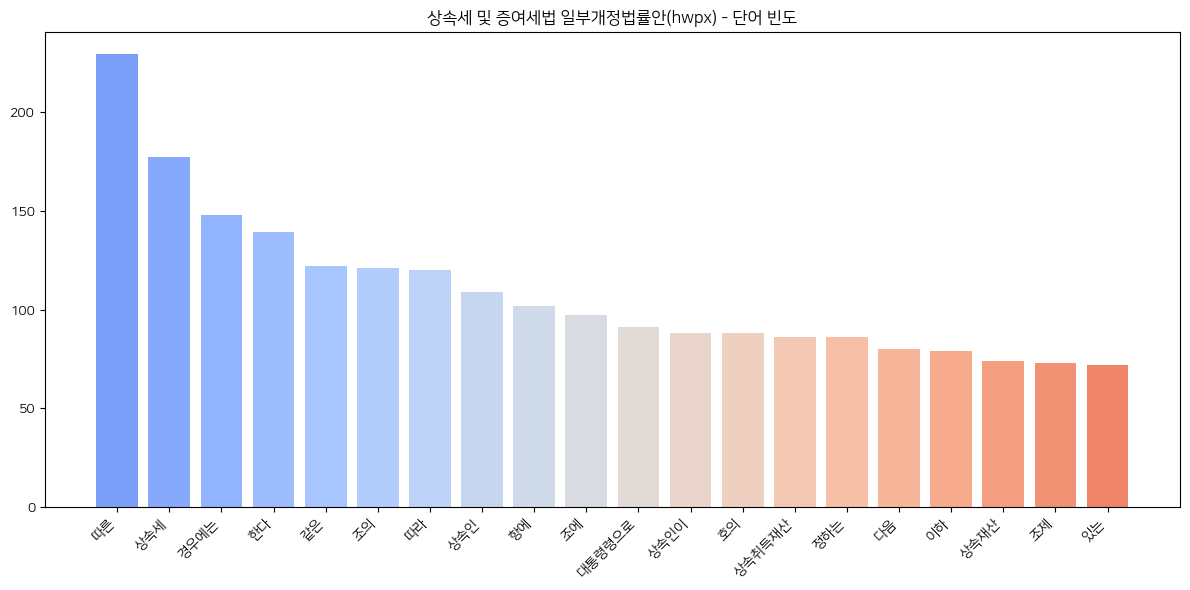


정규표현식 패턴 검색 결과:

'상속'으로 시작하는 단어 목록:
1. 상속개시
2. 상속개시일
3. 상속개시일까지의
4. 상속개시일부터
5. 상속개시일에
6. 상속개시일이
7. 상속개시지
8. 상속개시지가
9. 상속개시지를
10. 상속공제

'세' 또는 '법'으로 끝나는 단어 목록:
1. 65세
2. 계산방법
3. 공익신탁법
4. 과세
5. 과세방법
6. 국세기본법
7. 근로복지기본법
8. 민법
9. 법인세
10. 법인세법

가장 빈번한 공기어(연관어) 목록:
1. 대통령령으로 정하는: 83회
2. 항에 따른: 73회
3. 현행과 같음: 54회
4. 다음 호의: 52회
5. 상속인 수유자가: 47회
6. 이라 한다: 44회
7. 조에 따른: 44회
8. 조에 따라: 43회
9. 이하 조에서: 43회
10. 하고 같은: 42회

'상속세'가 등장하는 문맥:
1. 호제 호의결사항의 결연 상속세 증여세법 일부개정법률안제 자국무위원 기획재정부장관 제출 ...
2. 제출 연월일 법제처 심사 의결주문 상속세 증여세법 일부개정법률안을 별지와 같이 의결한다 ...
3. 일부개정법률안을 별지와 같이 의결한다 제안이유 상속세 과세체계 합리화를 위해 과세방식을 피상속인의 ...

'증여세'가 등장하는 문맥:
1. 내지 항을 준용한다 조의 항에서 증여세 상속세 본다 항부터 항까지의 규정을 ...
2. 해당 재산을 제외하고 계산한 증여자의 증여세 법에 따른 산출세액에서 공제 감면세액을 ...
3. 목의 금액을 합한 금액 증여자의 증여세 증여자의 상속세 우회상속인의 상속세 우회상속인의 ...


In [49]:
import warnings
warnings.filterwarnings('ignore')
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import nltk

# 한글 폰트 설치
!apt-get update -qq > /dev/null
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib

# 폰트 설정
import matplotlib.font_manager as fm
import matplotlib as mpl

font_paths = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
for font_path in font_paths:
    fm.fontManager.addfont(font_path)


plt.rcParams['font.family'] = 'NanumSquare'
plt.rcParams['axes.unicode_minus'] = False

# NLTK
nltk.download('punkt', quiet=True)

# 1. 텍스트 전처리
def preprocess_korean_text(text):
    text = re.sub(r'[^\w\s가-힣]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

preprocessed_text = preprocess_korean_text(hwpx_content)

# 2. 토큰화
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'[가-힣]{2,}')
tokens = tokenizer.tokenize(preprocessed_text)

# 3. 불용어 제거
korean_stopwords = ['이것', '그것', '저것', '경우', '등', '수', '및', '제', '법', '조', '항',
                    '이', '그', '저', '것', '등', '수', '및', '에서', '에게', '으로', '또는']
filtered_tokens = [token for token in tokens if token not in korean_stopwords]

# 4. 빈도 분석
from nltk.probability import FreqDist
fdist = FreqDist(filtered_tokens)
top_words = fdist.most_common(20)

print("\n문서에서 가장 빈번한 단어 20개:")
for i, (word, count) in enumerate(top_words, 1):
    print(f"{i}. {word}: {count}회")

# 5. 시각화
plt.figure(figsize=(12, 6))
words, counts = zip(*top_words)

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(words)))
bars = plt.bar(range(len(words)), counts, color=colors)

plt.xticks(range(len(words)), words, rotation=45, ha='right')
plt.title("상속세 및 증여세법 일부개정법률안(hwpx) - 단어 빈도")
plt.tight_layout()
plt.show()

# 6. 정규표현식 패턴 매칭
print("\n정규표현식 패턴 검색 결과:")

inheritance_patterns = re.findall(r'상속\w+', hwpx_content)
print("\n'상속'으로 시작하는 단어 목록:")
unique_patterns = sorted(set(inheritance_patterns))[:10]
for i, word in enumerate(unique_patterns, 1):
    print(f"{i}. {word}")

tax_law_words = re.findall(r'\w+[세법]\b', hwpx_content)
print(f"\n'세' 또는 '법'으로 끝나는 단어 목록:")
unique_tax_law = sorted(set(tax_law_words))[:10]
for i, word in enumerate(unique_tax_law, 1):
    print(f"{i}. {word}")

# 7. 공기어 분석
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(filtered_tokens)
finder.apply_freq_filter(3)

print("\n가장 빈번한 공기어(연관어) 목록:")
for i, (bigram, freq) in enumerate(finder.ngram_fd.most_common(10), 1):
    print(f"{i}. {' '.join(bigram)}: {freq}회")

# 8. 문맥 검색
def find_context(tokens, keyword, window=5):
    contexts = []
    for i in range(len(tokens)):
        if tokens[i] == keyword:
            start = max(0, i - window)
            end = min(len(tokens), i + window + 1)
            context = ' '.join(tokens[start:end])
            if len(contexts) < 3:
                contexts.append(context)
    return contexts

print("\n'상속세'가 등장하는 문맥:")
for i, context in enumerate(find_context(filtered_tokens, '상속세'), 1):
    print(f"{i}. {context} ...")

print("\n'증여세'가 등장하는 문맥:")
for i, context in enumerate(find_context(filtered_tokens, '증여세'), 1):
    print(f"{i}. {context} ...")

### LLM(claude) 붙여서 질의응답을 가능하게하기 - RAG 구축

In [50]:
%%capture
!pip install anthropic

In [61]:
# Claude API 활용 - RAG 시스템 구축
import numpy as np
import faiss
import tiktoken
import time
import requests
import json
from typing import List, Dict, Tuple

# Claude API 키 설정
import os
os.environ["ANTHROPIC_API_KEY"] = "이곳에 api key 를 입력해야합니다."
ANTHROPIC_API_KEY = os.environ["ANTHROPIC_API_KEY"]


CLAUDE_API_URL = "https://api.anthropic.com/v1/messages"
CLAUDE_EMBEDDING_URL = "https://api.anthropic.com/v1/embeddings"

# 1. 문서 청킹 - 텍스트를 일정 크기의 청크로 분할한다
def split_into_chunks(text: str, chunk_size: int = 1000, overlap: int = 200) -> List[str]:
    chunks = []
    start = 0
    text_length = len(text)
    while start < text_length:
        end = min(start + chunk_size, text_length)
        if end < text_length and text[end] != ' ':
            while end > start and text[end] != ' ':
                end -= 1
        chunk = text[start:end]
        chunks.append(chunk)
        start = end - overlap if end - overlap > start else end

    return chunks

# 2. 단순 키워드 기반 검색 함수
def keyword_search(chunks: List[str], query: str, k: int = 3) -> List[Tuple[str, float]]:
    keywords = query.lower().split()

    # 각 청크에 대해 점수 계산
    scores = []
    for chunk in chunks:
        chunk_lower = chunk.lower()
        score = sum(1 for keyword in keywords if keyword in chunk_lower)
        scores.append(score)

    # 상위 k개 청크 선택
    chunk_scores = list(zip(chunks, scores))
    chunk_scores.sort(key=lambda x: x[1], reverse=True)

    results = [(chunk, 1.0/(score+1)) for chunk, score in chunk_scores[:k] if score > 0]

    # 결과가 k개 미만이면 임의로 추가
    if len(results) < k:
        remaining = k - len(results)
        for chunk, _ in chunk_scores[len(results):len(results)+remaining]:
            results.append((chunk, 999.0))

    return results

# 3. 벡터 DB 구축 클래스 - 키워드 검색 사용
class SimpleSearchDB:
    def __init__(self, chunks: List[str]):
        self.chunks = chunks

    def search(self, query: str, k: int = 3) -> List[Tuple[str, float]]:
        """키워드 기반 검색 수행"""
        return keyword_search(self.chunks, query, k)

# 4. 토큰 카운터 함수 - 문자열의 토큰 수 계산
def num_tokens_from_string(string: str) -> int:
    return len(string) // 3  # 한국어 문자 3개당 약 1 토큰으로 계산

# 5. Claude API를 활용하여 LLM 호출 및 응답 생성
def call_claude_api(prompt: str, model: str = "claude-3-5-sonnet-20241022", temperature: float = 0.3) -> str:
    headers = {
        "x-api-key": ANTHROPIC_API_KEY,
        "anthropic-version": "2023-06-01",
        "content-type": "application/json"
    }

    data = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "temperature": temperature,
        "max_tokens": 1024
    }

    try:
        response = requests.post(
            CLAUDE_API_URL,
            headers=headers,
            json=data
        )

        if response.status_code == 200:
            response_data = response.json()
            return response_data["content"][0]["text"]
        else:
            print(f"Claude API 호출 오류: {response.status_code}, {response.text}")
            return f"오류 발생: {response.status_code}, {response.text}"

    except Exception as e:
        print(f"API 호출 중 오류 발생: {e}")
        return f"오류 발생: {e}"

# 6. RAG 질의응답 시스템 - 키워드 검색 기반 단순화
class RAGSystem:
    def __init__(self, text: str, chunk_size: int = 1000, overlap: int = 200):
        # 텍스트 청킹
        self.chunks = split_into_chunks(text, chunk_size, overlap)
        print(f"{len(self.chunks)}개의 청크 생성 완료")

        # 검색 DB 초기화
        self.search_db = SimpleSearchDB(self.chunks)

    def answer_question(self, question: str, model: str = "claude-3-5-sonnet-20241022", temperature: float = 0.3) -> str:
        # 관련 문서 검색
        relevant_chunks = self.search_db.search(question, k=3)

        # 컨텍스트 구성
        context = "\n\n".join([chunk for chunk, _ in relevant_chunks])

        # 프롬프트 구성
        prompt = f"""다음은 '상속세 및 증여세법 일부개정법률안'에서 추출한 내용입니다:

---
{context}
---

위 법률안의 내용을 바탕으로 다음 질문에 대해 정확하게 답변해주세요:

질문: {question}

답변 작성 지침:
1. 법률 내용을 정확하게 인용하되, 필요시 쉽게 풀어서 설명해주세요.
2. 법률 조항 번호나 항목 번호가 있다면 명시해주세요.
3. 법률 용어의 정의가 있다면 함께 설명해주세요.
4. 문서에서 확인할 수 없는 내용에 대해서는 "문서에서 해당 정보를 찾을 수 없습니다."라고 답변해주세요.
5. 답변은 논리적으로 구조화하고, 필요시 번호나 글머리 기호를 사용하여 가독성을 높여주세요.
6. 전문 용어가 많이 포함된 경우 일반인도 이해할 수 있도록 추가 설명을 제공해주세요."""

        # 토큰 수 계산 및 제한
        token_count = num_tokens_from_string(prompt)
        if token_count > 3800:
            print(f"프롬프트가 너무 깁니다: {token_count}토큰. 컨텍스트를 줄입니다.")
            # 컨텍스트 축소
            context_parts = []
            total_tokens = num_tokens_from_string(question) + 300

            for chunk, _ in relevant_chunks:
                chunk_tokens = num_tokens_from_string(chunk)
                if total_tokens + chunk_tokens < 3800:
                    context_parts.append(chunk)
                    total_tokens += chunk_tokens
                else:
                    break

            context = "\n\n".join(context_parts)
            prompt = f"""다음은 '상속세 및 증여세법 일부개정법률안'에서 추출한 내용입니다:

---
{context}
---

위 법률안의 내용을 바탕으로 다음 질문에 대해 정확하게 답변해주세요:

질문: {question}

답변 작성 지침:
1. 법률 내용을 정확하게 인용하되, 필요시 쉽게 풀어서 설명해주세요.
2. 법률 조항 번호나 항목 번호가 있다면 명시해주세요.
3. 법률 용어의 정의가 있다면 함께 설명해주세요.
4. 문서에서 확인할 수 없는 내용에 대해서는 "문서에서 해당 정보를 찾을 수 없습니다."라고 답변해주세요.
5. 답변은 논리적으로 구조화하고, 필요시 번호나 글머리 기호를 사용하여 가독성을 높여주세요.
6. 전문 용어가 많이 포함된 경우 일반인도 이해할 수 있도록 추가 설명을 제공해주세요."""

        # Claude API 호출
        print("답변을 불러오는 중입니다..")
        return call_claude_api(prompt, model, temperature)


def interactive_qa_system(rag_system):
    print("=" * 50)
    print("[상속세 및 증여세법 일부개정법률안 질의응답 시스템]")
    print("=" * 50)
    print("질문을 입력하면 관련 정보를 검색하여 답변합니다.")
    print("종료하려면 'q' 또는 'exit'를 입력하세요.")
    print("=" * 50)

    while True:
        query = input("\n질문을 입력하세요: ")
        if query.lower() in ['q', 'exit', '종료']:
            print("시스템을 종료합니다.")
            break

        start_time = time.time()
        answer = rag_system.answer_question(query)
        end_time = time.time()

        print(f"\n답변 (처리 시간: {end_time - start_time:.2f}초):")
        print("-" * 50)
        print(answer)
        print("-" * 50)

# RAG 시스템을 초기화하고 실행
try:
    rag_system = RAGSystem(extracted_text)

    print("\n질의응답 시스템을 시작합니다.")
    interactive_qa_system(rag_system)
except Exception as e:
    print(f"오류 발생: {e}")
    import traceback
    traceback.print_exc()

79개의 청크 생성 완료

질의응답 시스템을 시작합니다.
[상속세 및 증여세법 일부개정법률안 질의응답 시스템]
질문을 입력하면 관련 정보를 검색하여 답변합니다.
종료하려면 'q' 또는 'exit'를 입력하세요.

질문을 입력하세요: 시행일자가 어떻게 되나요?
답변을 불러오는 중입니다..

답변 (처리 시간: 4.28초):
--------------------------------------------------
주어진 법률안 내용에서는 시행일자가 명시되어 있지 않습니다. 

문서에는 다음과 같은 형식적인 정보만 포함되어 있습니다:
- 의안번호
- 제출자: 국무위원 ○○○(기획재정부장관)
- 입법예고 기간: 9999. 12. 31. ∼ 12. 31.

시행일자를 정확히 파악하기 위해서는 법률안의 부칙이나 추가 조항을 확인해야 하나, 제시된 문서에서는 해당 정보를 찾을 수 없습니다.
--------------------------------------------------

질문을 입력하세요: 실제로 주요 상속세의 변동사항에 대해서 정리해주세요. 
답변을 불러오는 중입니다..

답변 (처리 시간: 14.51초):
--------------------------------------------------
상속세 주요 변동사항을 다음과 같이 정리해드리겠습니다:

1. 과세체계의 기본 변경 (안 제3조의2)
- 기존: 피상속인의 상속재산 기준
- 변경: 상속인별로 취득한 재산 기준
- 의미: 각 상속인이 실제로 받은 재산에 따라 과세

2. 납세의무 기준 변경 (안 제3조, 제3조의2)
- 상속취득재산의 범위 결정 시 고려사항:
  * 상속인/수유자의 지위
  * 피상속인의 거주자 여부
- 특별 조항: 조세채권 확보가 어려운 경우 상속인 간 연대납세의무 부과

3. 공제제도 개편 (안 제18조, 제19조, 제20조, 제21조)
- 기초공제와 일괄공제 폐지
- 배우자 공제:
  * 법정상속분이 10억원 미만인 경우
  * 실제 상속받은 재산을 10억원 한도 내 공제
- 